In [12]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Dense,Dropout

In [14]:
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix

In [15]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [16]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


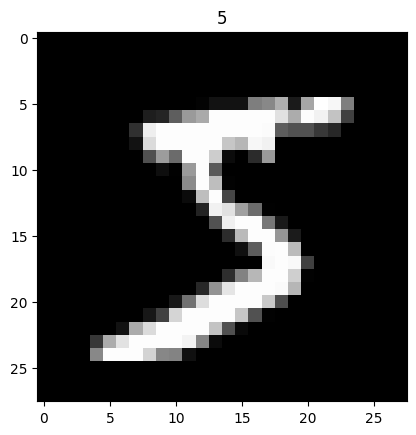

In [17]:
plt.imshow(X_train[0],cmap="gray")
plt.title(y_train[0])
plt.show()

In [18]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [19]:
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

In [20]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(60000, 784)
(60000,)
(10000, 784)
(10000,)


In [21]:
model = Sequential()

model.add(Dense(128, activation="relu", input_shape=(784,)))
model.add(Dropout(0.3))

model.add(Dense(64, activation="relu"))
model.add(Dropout(0.3))
model.add(Dense(64, activation="relu"))
model.add(Dense(32, activation="relu"))
model.add(Dense(10, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,306 (450.41 KB)

 Trainable params: 115,306 (450.41 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8537 - loss: 0.4706 - val_accuracy: 0.9568 - val_loss: 0.1552
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9329 - loss: 0.2286 - val_accuracy: 0.9611 - val_loss: 0.1302
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9469 - loss: 0.1796 - val_accuracy: 0.9674 - val_loss: 0.1144
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9534 - loss: 0.1594 - val_accuracy: 0.9688 - val_loss: 0.1094
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9585 - loss: 0.1424 - val_accuracy: 0.9708 - val_loss: 0.1060
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9611 - loss: 0.1298 - val_accuracy: 0.9708 - val_loss: 0.1000
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9637 - loss: 0.1235 - val_accuracy: 0.9732 - val_loss: 0.0943
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9648 - loss: 0.1170 -

In [25]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy :", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9753 - loss: 0.0914
Test Accuracy : 0.9753000140190125


In [26]:
y_prob = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [27]:
print(y_prob.shape)

(10000, 10)


In [28]:
y_pred = np.argmax(y_prob, axis=1)

In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.97      0.97      0.97      1032
           3       0.96      0.98      0.97      1010
           4       0.97      0.98      0.97       982
           5       0.98      0.97      0.98       892
           6       0.98      0.98      0.98       958
           7       0.97      0.97      0.97      1028
           8       0.97      0.96      0.97       974
           9       0.98      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [30]:
print(confusion_matrix(y_test, y_pred))

[[ 968    1    0    0    0    2    4    3    2    0]
 [   0 1123    1    3    0    0    3    0    5    0]
 [   3    4 1003   11    0    0    1    7    3    0]
 [   0    0    4  991    0    2    0    4    4    5]
 [   1    2    8    1  961    0    3    1    1    4]
 [   2    0    0    8    1  865    6    1    6    3]
 [   3    2    1    0    6    6  939    0    1    0]
 [   1    6   10    2    1    0    0 1000    1    7]
 [   4    1    3    6    4    6    2    5  939    4]
 [   4    5    0    7   17    1    0    9    2  964]]


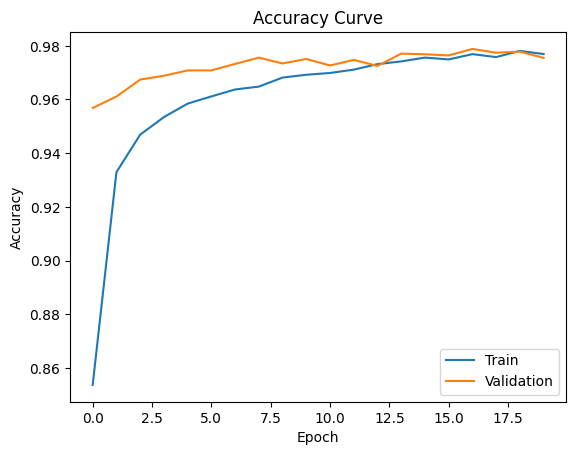

In [31]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.legend(["Train","Validation"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")

plt.show()

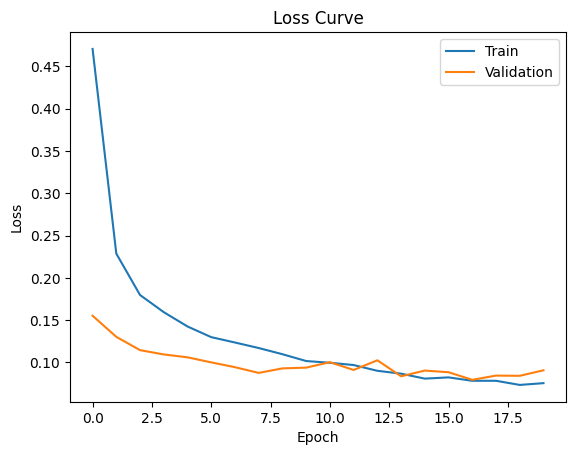

In [32]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.legend(["Train","Validation"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")

plt.show()